<a href="https://colab.research.google.com/github/Himanshu-5253/Descriptive/blob/main/MachineLearning_HPP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries


In [ ]:
import pandas as pd


Linear Regression Algorithm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [ ]:
housing_data = pd.read_csv('Housing.csv');
print(housing_data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
missing_values = housing_data.isnull().sum()
print(missing_values)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
#dropna()#dropna() is a Pandas function used to remove missing values (NaN) from a dataset.-> housing_data.dropna() -> It deletes rows or columns that contain missing values

# Making all the columns(data) in numerical fromat, so that analysis can be made easily

In [ ]:
categorical_colums = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']
for column in categorical_colums:
  housing_data[column] = housing_data[column].map({'yes':1,'no':0,'furnished':2,'semi-furnished':1,'unfurnished':0})

In [ ]:
print(housing_data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  


#Visualizing the Data / relationship between the targeted variable and the independent variable

Text(0.5, 1.0, 'Stories vs Price')

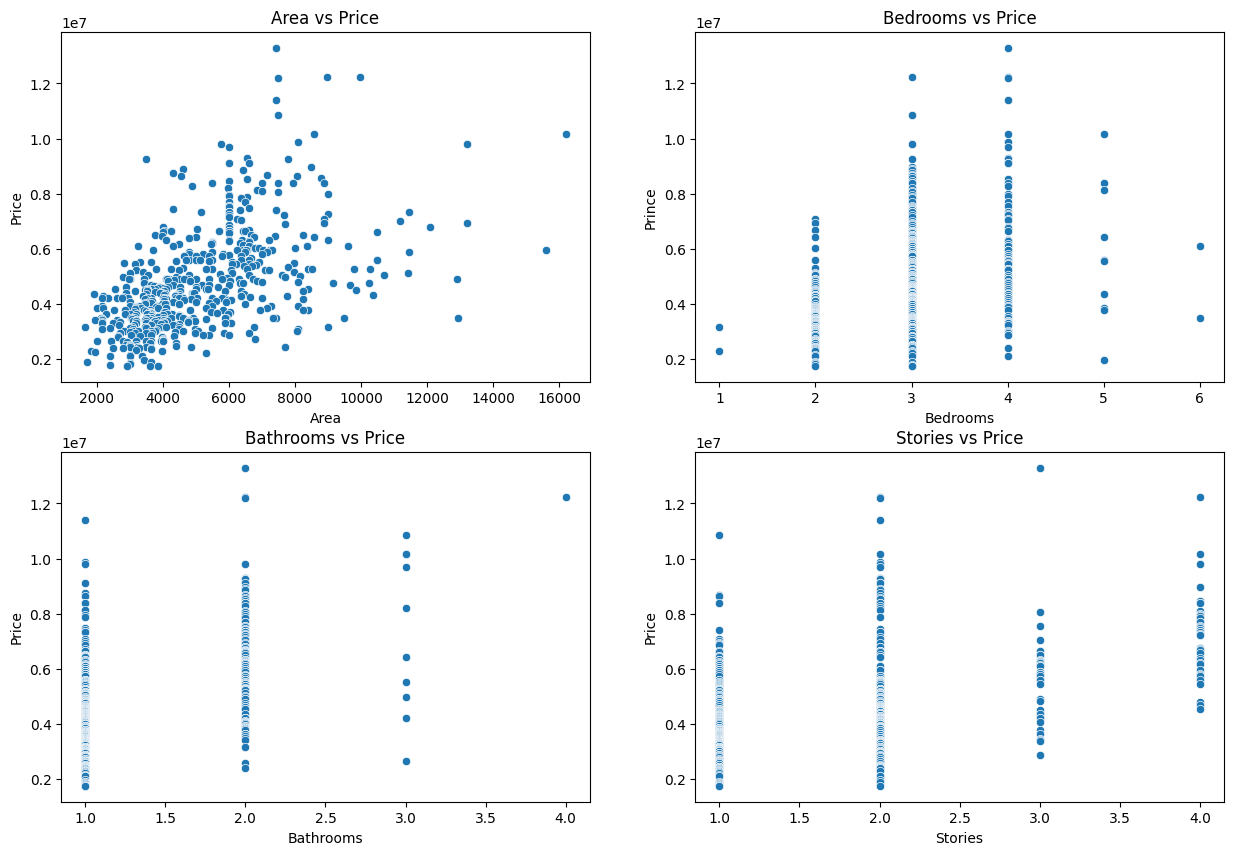

In [ ]:
plt.figure(figsize = (15,10))

plt.subplot(2,2,1)
sns.scatterplot(x='area',y='price',data=housing_data)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')

plt.subplot(2,2,2)
sns.scatterplot(x='bedrooms',y='price',data=housing_data)
plt.xlabel('Bedrooms')
plt.ylabel('Prince')
plt.title("Bedrooms vs Price")

plt.subplot(2,2,3)
sns.scatterplot(x='bathrooms',y='price',data=housing_data)
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.title("Bathrooms vs Price")

plt.subplot(2,2,4)
sns.scatterplot(x='stories',y='price',data=housing_data)
plt.xlabel('Stories')
plt.ylabel('Price')
plt.title("Stories vs Price")



#Splitting Data into Training and Testing


In [ ]:
X = housing_data.drop('price',axis = 1)
y=housing_data['price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)



#Applying Algorithm/Train the model


In [ ]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

#Testing the Model/predicting the test value



In [ ]:
y_pred = lm.predict(X_test)

#Evaluation


*   MSE- Mean Squared Error- How wrong the model is on the average
*   R^2(R-squared)-How well model explains the data(it values are the probabilities means if values are near to 1 then model is good and if the values are near to 0 then the model is bad)



In [ ]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Mean Squared Error: ",mse)
print("R^2 Score: ",r2)

Mean Squared Error:  0.0
R^2 Score:  1.0


To train the model on the same dataset we use another algorithm i.e,->


### *   Random Forest Algorithm
(this algo is used for regression and classification both (multiple decision trees) so therefore we use this here for regerssion )




In [ ]:
#from sklearn.ensemble import RandomForestRegressor #in case of classifiaction use -> RandomForestClassiifer

Apply the Algo/Train the model using this algorithm

In [ ]:
#rm = RandomForestRegressor(n_estimators=100,random_state=42)
#rm.fit(X_train,y_train)

In [ ]:
#rm_y_pred = rm.predict(X_test)

In [ ]:
#mse_rm = mean_squared_error(y_test,rm_y_pred)
#r2= r2_score(y_test,rm_y_pred)

#print("Mean Squared Error: ",mse_rm)
#print("R^2 Score: ",r2)

#House Price Prediction

In [ ]:
new_house_data = {
      'area':[2000],
      'bedrooms':[4],
      'bathrooms':[3],
      'stories':[2],
      'mainroad':[1],
      'guestroom':[1],
      'basement':[0],
      'hotwaterheating':[1],
      'airconditioning':[1],
      'parking':[1],
      'prefarea':[1],
      'furnishingstatus':[2]
}

new_house = pd.DataFrame(new_house_data,columns=X.columns)

predicted_price = lm.predict(new_house)
print("Predicted Price: ",predicted_price[0]);

Predicted Price:  8111937.732740659


#Saving the Trained Model

In [ ]:
import pickle

In [ ]:
filename = "trained_model.sav"
pickle.dump(lm, open(filename,'wb'))

In [ ]:
#loading the saved model
loaded_model = pickle.load(open('trained_model.sav', 'rb'))


In [ ]:
new_house_data = {
      'area':[2000],
      'bedrooms':[4],
      'bathrooms':[3],
      'stories':[2],
      'mainroad':[1],
      'guestroom':[1],
      'basement':[0],
      'hotwaterheating':[1],
      'airconditioning':[1],
      'parking':[1],
      'prefarea':[1],
      'furnishingstatus':[2]
}

new_house = pd.DataFrame(new_house_data,columns=X.columns)

predicted_price = loaded_model.predict(new_house)
print("Predicted Price: ",predicted_price[0]);

Predicted Price:  8111937.732740659
